100%|██████████| 170M/170M [00:03<00:00, 43.7MB/s]


Baseline
Epoch 1, Loss: 1279.045
Epoch 2, Loss: 1068.295
Epoch 3, Loss: 992.414
Epoch 4, Loss: 947.387
Epoch 5, Loss: 901.113

Hybrid WITHOUT attention
Epoch 1, Loss: 1475.983
Epoch 2, Loss: 1240.668
Epoch 3, Loss: 1176.292
Epoch 4, Loss: 1135.360
Epoch 5, Loss: 1104.461

Hybrid WITH attention
Epoch 1, Loss: 1500.919
Epoch 2, Loss: 1251.880
Epoch 3, Loss: 1146.492
Epoch 4, Loss: 1087.080
Epoch 5, Loss: 1048.073

Final Results:
Baseline: Acc=55.94, Precision=0.565, Recall=0.559, F1=0.556
Hybrid_No_Attn: Acc=48.50, Precision=0.485, Recall=0.485, F1=0.480
Hybrid_Attn: Acc=50.97, Precision=0.513, Recall=0.510, F1=0.506


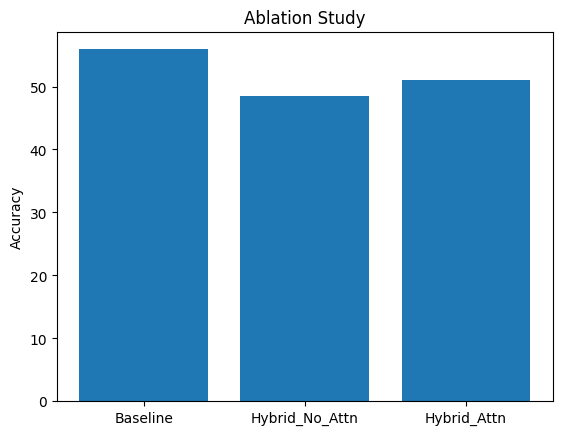

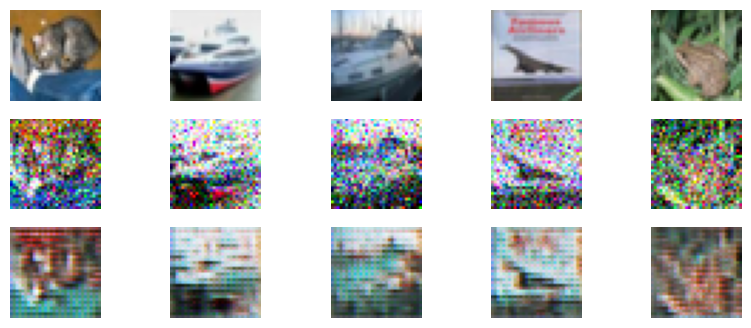

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# =======================
# SEED
# =======================
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =======================
# DATA (CIFAR-10)
# =======================
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# =======================
# NOISE (better than before)
# =======================
def add_noise(x):
    gauss = torch.randn_like(x) * 0.2
    x = torch.clamp(x + gauss, 0., 1.)

    # salt & pepper
    prob = 0.02
    salt = torch.rand_like(x) < prob
    pepper = torch.rand_like(x) < prob

    x[salt] = 1.0
    x[pepper] = 0.0

    return x

# fixed noisy test
torch.manual_seed(42)
fixed_noisy_test = []
for images, labels in testloader:
    noisy = add_noise(images)
    fixed_noisy_test.append((noisy, labels))

# =======================
# BASELINE CNN
# =======================
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16*16*32, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

# =======================
# SIMPLE ATTENTION
# =======================
class AttentionBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 1)
    def forward(self, x):
        attn = torch.sigmoid(self.conv(x))
        return x * attn

# =======================
# AUTOENCODER
# =======================
class AE(nn.Module):
    def __init__(self, use_attention=True):
        super().__init__()
        self.use_attention = use_attention

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.attn = AttentionBlock(32)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 32, 2, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        if self.use_attention:
            z = self.attn(z)
        recon = self.decoder(z)
        return recon

# =======================
# HYBRID MODEL
# =======================
class HybridModel(nn.Module):
    def __init__(self, use_attention=True):
        super().__init__()
        self.ae = AE(use_attention)

        self.classifier = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16*16*32, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        recon = self.ae(x)
        out = self.classifier(recon)
        return out, recon

# =======================
# TRAIN
# =======================
def train_model(model, is_hybrid=False):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    ce = nn.CrossEntropyLoss()
    mse = nn.MSELoss()

    for epoch in range(5):
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            noisy = add_noise(images)

            if is_hybrid:
                outputs, recon = model(noisy)
                loss = ce(outputs, labels) + 0.5 * mse(recon, images)
            else:
                outputs = model(noisy)
                loss = ce(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.3f}")

    return model

# =======================
# EVALUATION
# =======================
def evaluate_full(model, is_hybrid=False):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in fixed_noisy_test:
            images, labels = images.to(device), labels.to(device)

            if is_hybrid:
                outputs, _ = model(images)
            else:
                outputs = model(images)

            _, pred = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    acc = 100 * np.mean(np.array(y_true) == np.array(y_pred))
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, precision, recall, f1

# =======================
# VISUALIZATION
# =======================
def show_reconstruction(model):
    model.eval()
    images, _ = next(iter(testloader))
    noisy = add_noise(images)

    with torch.no_grad():
        _, recon = model(noisy.to(device))

    plt.figure(figsize=(10,4))
    for i in range(5):
        plt.subplot(3,5,i+1)
        plt.imshow(images[i].permute(1,2,0))
        plt.axis('off')

        plt.subplot(3,5,i+6)
        plt.imshow(noisy[i].permute(1,2,0))
        plt.axis('off')

        plt.subplot(3,5,i+11)
        plt.imshow(recon[i].cpu().permute(1,2,0))
        plt.axis('off')

    plt.show()

# =======================
# TRAIN ALL
# =======================
print("Baseline")
baseline = train_model(BaselineCNN(), False)

print("\nHybrid WITHOUT attention")
hybrid_no_attn = train_model(HybridModel(False), True)

print("\nHybrid WITH attention")
hybrid_attn = train_model(HybridModel(True), True)

# =======================
# RESULTS
# =======================
models = {
    "Baseline": baseline,
    "Hybrid_No_Attn": hybrid_no_attn,
    "Hybrid_Attn": hybrid_attn
}

results = {}

for name, model in models.items():
    is_hybrid = "Hybrid" in name
    results[name] = evaluate_full(model, is_hybrid)

print("\nFinal Results:")
for k, v in results.items():
    print(f"{k}: Acc={v[0]:.2f}, Precision={v[1]:.3f}, Recall={v[2]:.3f}, F1={v[3]:.3f}")

# =======================
# PLOT
# =======================
names = list(results.keys())
accs = [results[n][0] for n in names]

plt.figure()
plt.bar(names, accs)
plt.ylabel("Accuracy")
plt.title("Ablation Study")
plt.show()

# =======================
# SHOW RECONSTRUCTION
# =======================
show_reconstruction(hybrid_attn)